In [106]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

In [107]:
start, end = '2022-01-01', '2026-01-01'

close_prices = yf.download('SPY', start=start, end=end, interval='1d', auto_adjust=True)['Close']

print(f'Shape: {close_prices.shape}')
display(close_prices.head())
display(close_prices.describe())
display(close_prices.info())

# convert dataframe to series (use SPY for now)
close_prices = close_prices['SPY']

[*********************100%***********************]  1 of 1 completed

Shape: (1003, 1)


Ticker,SPY
Date,
2022-01-03,450.644440
2022-01-04,450.493530
2022-01-05,441.843048
2022-01-06,441.427917
2022-01-07,439.682800


Ticker,SPY
count,1003.000000
mean,486.070601
std,97.814339
min,340.252838
25%,397.365036
50%,461.188232
75%,569.474579
max,688.499695


<class 'pandas.DataFrame'>
DatetimeIndex: 1003 entries, 2022-01-03 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SPY     1003 non-null   float64
dtypes: float64(1)
memory usage: 15.7 KB


None

In [108]:
# grid search over feature windows using BIC
# n_components fixed at 4 (Guidolin & Timmermann 2007 — BIC unreliable for n_components on sequential data)
# sma_window removed — raw log return is literature standard (sma_window=1 equivalent)
from itertools import product

vol_windows = [5, 10, 20]
dd_windows = [30, 45, 60]
n_components = 4

grid_results = []

for vw, dw in product(vol_windows, dd_windows):
    lr = np.log(close_prices / close_prices.shift(1)).dropna()
    rv = lr.rolling(window=vw).std()
    rm = close_prices.rolling(window=dw).max()
    dd = (close_prices - rm) / close_prices

    X = pd.DataFrame({
        'log_return': lr,
        'rolling_vol': rv,
        'drawdown': dd,
    }).dropna()

    sc = StandardScaler()
    X_scaled = sc.fit_transform(X)

    m = GaussianHMM(n_components=n_components, covariance_type='full', n_iter=1000, random_state=42)
    m.fit(X_scaled)

    n_features = X.shape[1]
    k = n_components * (n_components - 1) + n_components * n_features + n_components * n_features * (n_features + 1) // 2
    n = len(X_scaled)
    ll = m.score(X_scaled)
    bic = k * np.log(n) - 2 * ll

    grid_results.append({
        'vol_window': vw,
        'dd_window': dw,
        'bic': round(bic, 2),
        'log_likelihood': round(ll, 2),
        'converged': m.monitor_.converged,
    })

grid_df = pd.DataFrame(grid_results).sort_values('bic').reset_index(drop=True)
display(grid_df)

,vol_window,dd_window,bic,log_likelihood,converged
0,20,60,3419.35,-1545.27,True
1,10,60,3504.39,-1587.79,True
2,10,45,3511.00,-1590.72,True
3,5,60,3632.13,-1651.66,True
4,20,45,3785.39,-1727.91,True
5,5,45,3900.48,-1785.46,True
6,20,30,4075.19,-1872.44,True
7,5,30,4107.90,-1888.80,True
8,10,30,4317.13,-1993.41,True


In [109]:
# derive features (returns, volatility, drawdowns)
vol_window = 20
drawdown_window = 60

log_returns = np.log(close_prices / close_prices.shift(1)).dropna()
rolling_vol = log_returns.rolling(window=vol_window).std()
rolling_max = close_prices.rolling(window=drawdown_window).max()
drawdowns = (close_prices - rolling_max) / close_prices

features = pd.DataFrame({
    'log_return': log_returns,
    'rolling_vol': rolling_vol,
    'drawdown': drawdowns,
}).dropna()

print(f'Shape: {features.shape}')
display(features.head())
display(features.describe())

Shape: (944, 3)


,log_return,rolling_vol,drawdown
Date,,,
2022-03-29,0.012295,0.014548,-0.031807
2022-03-30,-0.006194,0.014287,-0.037870
2022-03-31,-0.015511,0.014762,-0.039680
2022-04-01,0.002830,0.014570,-0.036742
2022-04-04,0.008530,0.012449,-0.027936


,log_return,rolling_vol,drawdown
count,944.000000,944.000000,944.000000
mean,0.000482,0.010061,-0.037573
std,0.011166,0.005132,0.051087
min,-0.060327,0.003410,-0.258830
25%,-0.004548,0.006730,-0.051500
50%,0.000671,0.008663,-0.014213
75%,0.006265,0.011811,-0.002565
max,0.099863,0.033851,0.000000


In [110]:
feature_cols = ['log_return', 'rolling_vol', 'drawdown']
n_components = 4

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[feature_cols])

model = GaussianHMM(n_components=n_components, covariance_type='full', n_iter=1000, random_state=42)
model.fit(X_scaled)

# regime means
regime_means = pd.DataFrame(scaler.inverse_transform(model.means_), columns=feature_cols)

# label regimes by drawdown rank (most negative = Bear)
sorted_labels = regime_means['drawdown'].argsort()
label_map = {
    sorted_labels.iloc[0]: 'Bear',
    sorted_labels.iloc[1]: 'Correction',
    sorted_labels.iloc[2]: 'Recovery',
    sorted_labels.iloc[3]: 'Bull',
}
regime_labels = [label_map[i] for i in range(n_components)]
regime_means.index = regime_labels

# map regimes to labels
features['regime'] = pd.Series(model.predict(X_scaled), index=features.index).map(label_map)

# transition matrix
transition_matrix = pd.DataFrame(model.transmat_, index=regime_labels, columns=regime_labels)

print(f"\nRegime counts:\n{features['regime'].value_counts()}")
print(f'Converged: {model.monitor_.converged}')
print(f'Log-likelihood: {model.score(X_scaled):.2f}')
print('\nRegime means:')
display(regime_means.round(4))
print('Transition matrix:')
display(transition_matrix.round(3))


Regime counts:
regime
Bull          356
Recovery      284
Correction    205
Bear           99
Name: count, dtype: int64
Converged: True
Log-likelihood: -1545.27

Regime means:


,log_return,rolling_vol,drawdown
Bull,0.0015,0.0065,-0.0031
Bear,-0.0011,0.0181,-0.1558
Correction,-0.0002,0.0138,-0.0658
Recovery,0.0002,0.0090,-0.0194


Transition matrix:


,Bull,Bear,Correction,Recovery
Bull,0.951,0.000,0.000,0.049
Bear,0.000,0.970,0.030,0.000
Correction,0.000,0.015,0.951,0.034
Recovery,0.064,0.000,0.020,0.916


Regime Duration Stats (trading days)


,min,max,mean,count
regime,,,,
Bear,5,54,33.0,3
Bull,2,59,20.9,17
Correction,9,40,22.8,9
Recovery,2,35,12.9,22


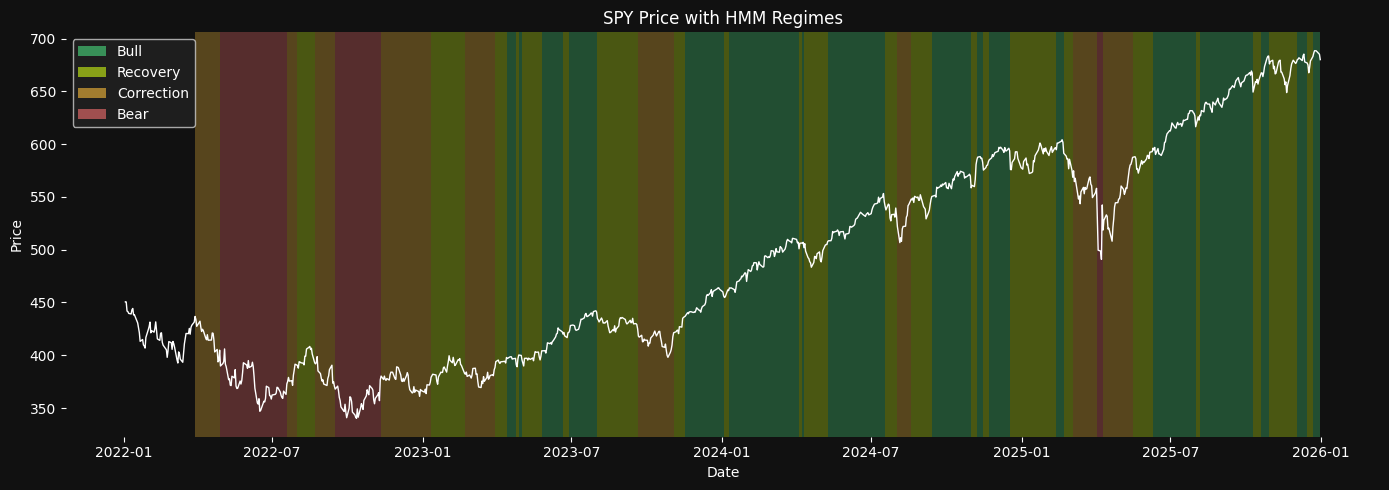

In [111]:
# regime duration stats
runs, current, count = [], features['regime'].iloc[0], 1
for label in features['regime'].iloc[1:]:
    if label == current:
        count += 1
    else:
        runs.append({'regime': current, 'duration': count})
        current, count = label, 1
runs.append({'regime': current, 'duration': count})

runs_df = pd.DataFrame(runs)
print('Regime Duration Stats (trading days)')
display(runs_df.groupby('regime')['duration'].agg(['min', 'max', 'mean', 'count']).round(1))

# ------------------------------------------------
#             PLOT REGIMES
# ------------------------------------------------
from matplotlib.patches import Patch

palette = {
    'Bull':       '#4ade80',
    'Bear':       '#f87171',
    'Recovery':   "#d0fa15",
    'Correction': "#fbbe3c",
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(close_prices.index, close_prices, color='white', linewidth=1, zorder=2)

current_label, start_idx = features['regime'].iloc[0], features.index[0]
for date, label in features['regime'].items():
    if label != current_label:
        ax.axvspan(start_idx, date, color=palette[current_label], alpha=0.3, lw=0, zorder=1)
        current_label, start_idx = label, date
ax.axvspan(start_idx, features.index[-1], color=palette[current_label], alpha=0.3, lw=0, zorder=1)

legend_elements = [Patch(facecolor=palette[r], alpha=0.6, label=r) for r in ['Bull', 'Recovery', 'Correction', 'Bear']]
ax.set_title('SPY Price with HMM Regimes')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.set_facecolor('#111111')
fig.patch.set_facecolor('#111111')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(handles=legend_elements, loc='upper left', facecolor='#222222', labelcolor='white')

plt.tight_layout()
plt.show()